# MScFE 632: Machine Learning in Finance
## Group Work Project 2 Group 15901

Issue 1: Eric Ackonu Ghana Ericackonu6@gmail.com

Issue 2: Hillary Maina Irungu Kenya hmirungu@gmail.com

Issue 3: Srikanth Seekar India srikanthseekar1997@gmail.com

In [61]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier

from sklearn.base import clone
from sklearn.exceptions import ConvergenceWarning

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold
)

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.tree import DecisionTreeClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import (
    BaggingClassifier,
    AdaBoostClassifier,
    StackingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

warnings.filterwarnings(
    "ignore",
    category=ConvergenceWarning
)

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)

np.random.seed(42)
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True

X_raw, y = make_classification(
    n_samples=2000,
    n_features=12,
    n_informative=7,
    n_redundant=3,
    n_classes=2,
    class_sep=0.80,
    flip_y=0.04,
    weights=[0.50, 0.50],
    random_state=42
)

feature_names = [
    "momentum_1m", "momentum_6m", "volatility", "liquidity",
    "value_score", "quality_score", "carry", "term_spread",
    "credit_spread", "vix_change", "dollar_change", "commodity_change"
]

X = pd.DataFrame(X_raw, columns=feature_names)
y = pd.Series(y, name="next_return_direction")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))
display(X.head().round(3))
display(y.value_counts(normalize=True).rename("Class Proportion").round(3))

Training observations: 1400
Testing observations: 600


,momentum_1m,momentum_6m,volatility,liquidity,value_score,quality_score,carry,term_spread,credit_spread,vix_change,dollar_change,commodity_change
0,0.272,1.265,0.538,-3.080,-1.427,3.151,2.560,5.605,-2.804,3.110,0.261,3.013
1,-1.405,1.440,0.959,2.850,2.213,-1.263,-1.683,0.750,-1.508,-5.101,1.998,-0.376
2,0.783,-1.406,5.043,0.467,-0.361,3.953,0.981,4.943,-3.038,3.778,-1.541,-0.759
3,-0.831,-1.415,-0.664,0.580,-1.627,-0.687,0.322,-1.853,1.206,0.926,1.228,1.373
4,0.584,0.358,-0.750,-0.253,-1.957,-1.648,-1.780,-0.900,-0.624,-1.483,1.636,0.209


,Class Proportion
next_return_direction,
1,0.503
0,0.496


#Issue 1: Optimizing Hyperparameters
Author: Student A, Reviewer: Student B

This notebook contains the computation for Issue 1 only. It illustrates:

the difference between default and tuned model settings;
Grid Search and Randomized Search;
five-fold cross-validation;
out-of-sample model comparison;
a validation curve;
interpretation and a recommended course of action.

###1. Finance-Style Dataset

In [62]:
X_raw, y = make_classification(
    n_samples=2000,
    n_features=12,
    n_informative=7,
    n_redundant=3,
    n_classes=2,
    class_sep=0.80,
    flip_y=0.04,
    weights=[0.50, 0.50],
    random_state=42
)

feature_names = [
    "momentum_1m", "momentum_6m", "volatility", "liquidity",
    "value_score", "quality_score", "carry", "term_spread",
    "credit_spread", "vix_change", "dollar_change", "commodity_change"
]

X = pd.DataFrame(X_raw, columns=feature_names)
y = pd.Series(y, name="next_return_direction")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))
display(X.head().round(3))
display(y.value_counts(normalize=True).rename("Class Proportion").round(3))

Training observations: 1400
Testing observations: 600


,momentum_1m,momentum_6m,volatility,liquidity,value_score,quality_score,carry,term_spread,credit_spread,vix_change,dollar_change,commodity_change
0,0.272,1.265,0.538,-3.080,-1.427,3.151,2.560,5.605,-2.804,3.110,0.261,3.013
1,-1.405,1.440,0.959,2.850,2.213,-1.263,-1.683,0.750,-1.508,-5.101,1.998,-0.376
2,0.783,-1.406,5.043,0.467,-0.361,3.953,0.981,4.943,-3.038,3.778,-1.541,-0.759
3,-0.831,-1.415,-0.664,0.580,-1.627,-0.687,0.322,-1.853,1.206,0.926,1.228,1.373
4,0.584,0.358,-0.750,-0.253,-1.957,-1.648,-1.780,-0.900,-0.624,-1.483,1.636,0.209


,Class Proportion
next_return_direction,
1,0.503
0,0.496


2. Baseline Model

In [63]:
baseline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=5000, random_state=42))
])

baseline.fit(X_train, y_train)
baseline_pred = baseline.predict(X_test)
baseline_proba = baseline.predict_proba(X_test)[:, 1]

baseline_results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    "Baseline": [
        accuracy_score(y_test, baseline_pred),
        precision_score(y_test, baseline_pred),
        recall_score(y_test, baseline_pred),
        f1_score(y_test, baseline_pred),
        roc_auc_score(y_test, baseline_proba)
    ]
})

display(baseline_results.round(4))

,Metric,Baseline
0,Accuracy,0.7733
1,Precision,0.8029
2,Recall,0.7285
3,F1-score,0.7639
4,ROC-AUC,0.8421


3. Grid Search: Regularized Logistic Regression

In [64]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

logit_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=5000, random_state=42))
])

logit_grid = {
    "model__C": [0.001, 0.01, 0.1, 1, 10, 100],
    "model__penalty": ["l2"],
    "model__solver": ["lbfgs"]
}

logit_search = GridSearchCV(
    logit_pipeline,
    logit_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    return_train_score=True
)

logit_search.fit(X_train, y_train)

print("Best parameters:", logit_search.best_params_)
print("Best CV ROC-AUC:", round(logit_search.best_score_, 4))

logit_results = pd.DataFrame(logit_search.cv_results_)[[
    "param_model__C", "mean_train_score", "mean_test_score",
    "std_test_score", "rank_test_score"
]].sort_values("rank_test_score")

display(logit_results.round(4))

Best parameters: {'model__C': 1, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
Best CV ROC-AUC: 0.8381


,param_model__C,mean_train_score,mean_test_score,std_test_score,rank_test_score
3,1.000,0.8431,0.8381,0.0293,1
5,100.000,0.8431,0.8380,0.0294,2
4,10.000,0.8431,0.8380,0.0294,3
2,0.100,0.8427,0.8377,0.0294,4
1,0.010,0.8388,0.8348,0.0294,5
0,0.001,0.8274,0.8239,0.0297,6


4. Grid Search: Support Vector Machine

In [65]:
svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(probability=True, random_state=42))
])

svm_grid = {
    "model__C": [0.1, 1, 10],
    "model__kernel": ["linear", "rbf"],
    "model__gamma": ["scale", "auto"]
}

svm_search = GridSearchCV(
    svm_pipeline,
    svm_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    return_train_score=True
)

svm_search.fit(X_train, y_train)

print("Best parameters:", svm_search.best_params_)
print("Best CV ROC-AUC:", round(svm_search.best_score_, 4))

svm_results = pd.DataFrame(svm_search.cv_results_)[[
    "param_model__C", "param_model__kernel", "param_model__gamma",
    "mean_train_score", "mean_test_score", "std_test_score",
    "rank_test_score"
]].sort_values("rank_test_score")

display(svm_results.head(10).round(4))

Best parameters: {'model__C': 1, 'model__gamma': 'scale', 'model__kernel': 'rbf'}
Best CV ROC-AUC: 0.9437


,param_model__C,param_model__kernel,param_model__gamma,mean_train_score,mean_test_score,std_test_score,rank_test_score
7,1.0,rbf,auto,0.9656,0.9437,0.0179,1
5,1.0,rbf,scale,0.9656,0.9437,0.0179,1
11,10.0,rbf,auto,0.9874,0.9432,0.0129,3
9,10.0,rbf,scale,0.9874,0.9432,0.0129,3
1,0.1,rbf,scale,0.9216,0.9104,0.0261,5
3,0.1,rbf,auto,0.9216,0.9104,0.0261,5
4,1.0,linear,scale,0.8429,0.8403,0.0296,7
6,1.0,linear,auto,0.8429,0.8403,0.0296,7
8,10.0,linear,scale,0.8429,0.8402,0.0296,9
10,10.0,linear,auto,0.8429,0.8402,0.0296,9


5. Randomized Search: Random Forest

In [69]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42, n_jobs=-1)

rf_param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [3, 5, 8, 12, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "max_features": ["sqrt", "log2", None]
}

rf_search = RandomizedSearchCV(
    rf,
    rf_param_dist,
    n_iter=30,
    cv=cv,
    scoring="roc_auc",
    random_state=42,
    n_jobs=-1,
    return_train_score=True
)

rf_search.fit(X_train, y_train)

print("Best parameters:", rf_search.best_params_)
print("Best CV ROC-AUC:", round(rf_search.best_score_, 4))

rf_results = pd.DataFrame(rf_search.cv_results_)[[
    "params", "mean_train_score", "mean_test_score",
    "std_test_score", "rank_test_score"
]].sort_values("rank_test_score")

display(rf_results.head(10).round(4))

Best parameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None}
Best CV ROC-AUC: 0.9331


,params,mean_train_score,mean_test_score,std_test_score,rank_test_score
18,"{'n_estimators': 200, 'min_samples_split': 2, ...",0.9999,0.9331,0.0210,1
14,"{'n_estimators': 300, 'min_samples_split': 5, ...",0.9999,0.9330,0.0225,2
10,"{'n_estimators': 100, 'min_samples_split': 2, ...",1.0000,0.9328,0.0231,3
0,"{'n_estimators': 100, 'min_samples_split': 5, ...",1.0000,0.9308,0.0232,4
20,"{'n_estimators': 200, 'min_samples_split': 2, ...",0.9999,0.9273,0.0244,5
17,"{'n_estimators': 100, 'min_samples_split': 2, ...",0.9942,0.9260,0.0250,6
24,"{'n_estimators': 100, 'min_samples_split': 2, ...",0.9997,0.9258,0.0253,7
4,"{'n_estimators': 500, 'min_samples_split': 10,...",0.9980,0.9253,0.0244,8
22,"{'n_estimators': 100, 'min_samples_split': 2, ...",0.9940,0.9241,0.0244,9
27,"{'n_estimators': 300, 'min_samples_split': 5, ...",0.9866,0.9233,0.0230,10


rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

rf_param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [3, 5, 8, 12, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "max_features": ["sqrt", "log2", None]
}

rf_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_param_dist,
    n_iter=30,
    cv=cv,
    scoring="roc_auc",
    random_state=42,
    n_jobs=-1,
    return_train_score=True
)

rf_search.fit(X_train, y_train)

print("Best parameters:", rf_search.best_params_)
print("Best CV ROC-AUC:", round(rf_search.best_score_, 4))

rf_results = (
    pd.DataFrame(rf_search.cv_results_)[
        [
            "params",
            "mean_train_score",
            "mean_test_score",
            "std_test_score",
            "rank_test_score",
        ]
    ]
    .sort_values("rank_test_score")
)

display(rf_results.head(10).round(4))

6. Out-of-Sample Comparison

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
2,Tuned SVM,0.8900,0.8960,0.8841,0.8900,0.9394
3,Tuned Random Forest,0.8667,0.8801,0.8510,0.8653,0.9255
1,Tuned Logistic Regression,0.7733,0.8029,0.7285,0.7639,0.8421
0,Baseline Logistic Regression,0.7733,0.8029,0.7285,0.7639,0.8421


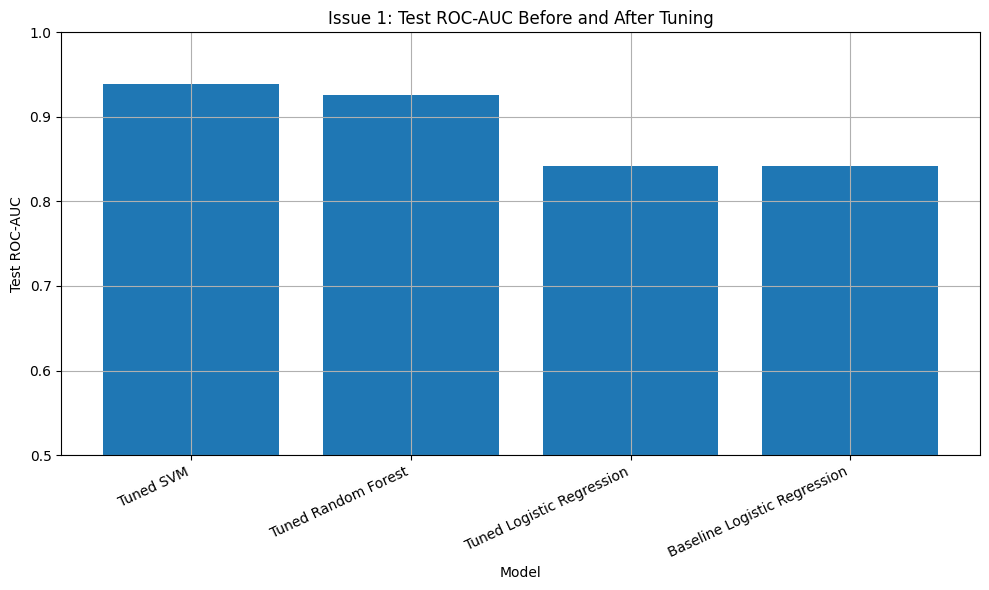

In [70]:
best_models = {
    "Baseline Logistic Regression": baseline,
    "Tuned Logistic Regression": logit_search.best_estimator_,
    "Tuned SVM": svm_search.best_estimator_,
    "Tuned Random Forest": rf_search.best_estimator_
}

rows = []

for name, model in best_models.items():
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]

    rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1-score": f1_score(y_test, pred),
        "ROC-AUC": roc_auc_score(y_test, proba)
    })

comparison = pd.DataFrame(rows).sort_values("ROC-AUC", ascending=False)
display(comparison.round(4))

plt.bar(comparison["Model"], comparison["ROC-AUC"])
plt.title("Issue 1: Test ROC-AUC Before and After Tuning")
plt.xlabel("Model")
plt.ylabel("Test ROC-AUC")
plt.ylim(0.50, 1.00)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

## 7. Validation Curve

,max_depth,Mean Training ROC-AUC,Mean Validation ROC-AUC,Validation Standard Deviation
0,2,0.8705,0.8423,0.0401
1,3,0.9039,0.8688,0.0341
2,4,0.9328,0.8885,0.0330
3,5,0.9570,0.9047,0.0277
4,6,0.9754,0.9160,0.0251
5,8,0.9942,0.9267,0.0243
6,10,0.9990,0.9320,0.0222
7,12,0.9998,0.9343,0.0213
8,15,0.9999,0.9333,0.0210
9,20,0.9999,0.9331,0.0210


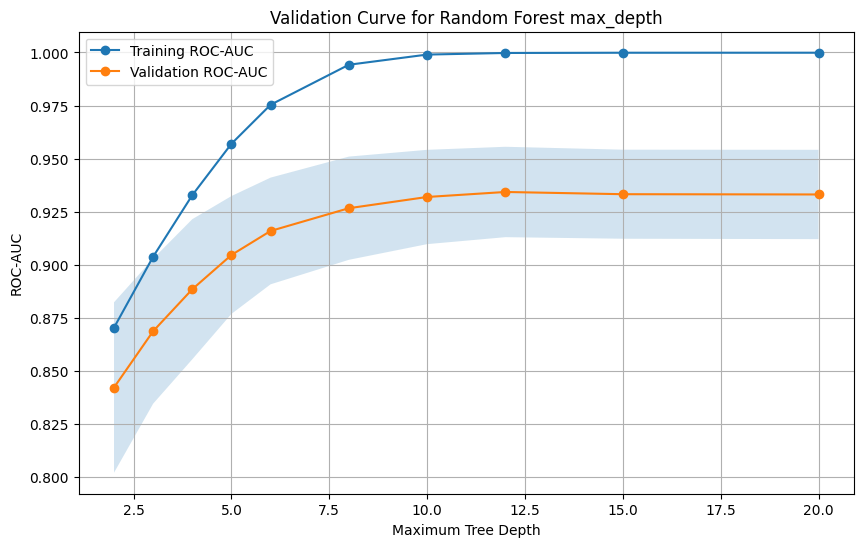

In [71]:
depth_range = [2, 3, 4, 5, 6, 8, 10, 12, 15, 20]

train_scores, validation_scores = validation_curve(
    RandomForestClassifier(
        n_estimators=200,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ),
    X_train,
    y_train,
    param_name="max_depth",
    param_range=depth_range,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
validation_mean = validation_scores.mean(axis=1)
validation_std = validation_scores.std(axis=1)

validation_table = pd.DataFrame({
    "max_depth": depth_range,
    "Mean Training ROC-AUC": train_mean,
    "Mean Validation ROC-AUC": validation_mean,
    "Validation Standard Deviation": validation_std
})

display(validation_table.round(4))

plt.plot(depth_range, train_mean, marker="o", label="Training ROC-AUC")
plt.plot(depth_range, validation_mean, marker="o", label="Validation ROC-AUC")
plt.fill_between(
    depth_range,
    validation_mean - validation_std,
    validation_mean + validation_std,
    alpha=0.20
)
plt.title("Validation Curve for Random Forest max_depth")
plt.xlabel("Maximum Tree Depth")
plt.ylabel("ROC-AUC")
plt.legend()
plt.show()

8. Interpretation and Recommended Course of Action
The preferred settings should satisfy three conditions:

strong average cross-validation performance;
strong performance on the untouched test sample;
reasonable stability across validation folds.
The investment team should use the best cross-validated configuration as a candidate, confirm it on a later holdout period, and retune the settings periodically as market conditions change.

In [72]:
best_row = comparison.iloc[0]

print("Recommended model:", best_row["Model"])
print("Test ROC-AUC:", round(best_row["ROC-AUC"], 4))
print("Test Accuracy:", round(best_row["Accuracy"], 4))
print(
    "Recommendation: use the best cross-validated configuration, "
    "confirm it on a later holdout period, and monitor it through time."
)

Recommended model: Tuned SVM
Test ROC-AUC: 0.9394
Test Accuracy: 0.89
Recommendation: use the best cross-validated configuration, confirm it on a later holdout period, and monitor it through time.


#Issue 2: Hillary Maina Irungu Kenya hmirungu@gmail.com

   Depth  Training Accuracy  Validation Accuracy
0      1          92.838864            89.186709
1      2          96.168057            91.696203
2      3          97.424144            92.708861
3      4          98.491749            91.202532
4      5          98.994105            92.971519
5      6          99.559946            91.458861
6      7          99.811321            91.205696
7      8          99.937107            90.955696
8      9         100.000000            90.955696
9     10         100.000000            90.955696


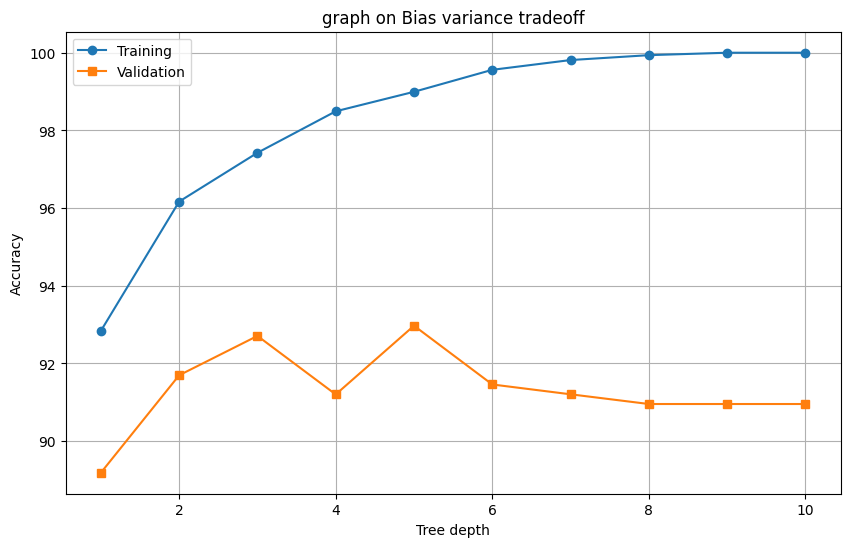

In [73]:
# data
X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=37, stratify=y
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []

for depth in range(1, 11):

    model = DecisionTreeClassifier(max_depth=depth, random_state=42)

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="accuracy",
        return_train_score=True
    )

    results.append([
    depth,
    scores["train_score"].mean() * 100,
    scores["test_score"].mean() * 100
])

results = pd.DataFrame(
    results,
    columns=["Depth", "Training Accuracy", "Validation Accuracy"]
)

print(results)

# Plot visuals
plt.plot(results["Depth"], results["Training Accuracy"], marker="o", label="Training")
plt.plot(results["Depth"], results["Validation Accuracy"], marker="s", label="Validation")

plt.xlabel("Tree depth")
plt.ylabel("Accuracy")
plt.title("graph on Bias variance tradeoff")
plt.legend()
plt.grid(True)
plt.show()

Recreate the GWP1 financial dataset

In [74]:
# ============================================================
# GWP1 DATA USED FOR ISSUE 3
# ============================================================

def create_gwp1_financial_data():
    """
    Recreates the 650-observation financial dataset used in
    the submitted GWP1 notebook.
    """

    rng = np.random.RandomState(42)

    # Advance the local random state through the earlier
    # demonstration performed in the original GWP1 notebook.
    earlier_sample_size = 600

    rng.normal(
        loc=0,
        scale=0.015,
        size=earlier_sample_size
    )

    rng.normal(
        loc=0.02,
        scale=0.01,
        size=earlier_sample_size
    )

    rng.normal(
        loc=0,
        scale=1,
        size=earlier_sample_size
    )

    rng.normal(
        loc=0.001,
        scale=0.0005,
        size=earlier_sample_size
    )

    rng.normal(
        loc=0,
        scale=0.01,
        size=earlier_sample_size
    )

    # Reproduce the random-state advancement made during
    # the earlier classification calculation.
    rng.randint(np.iinfo("i").max)

    # Main group financial dataset
    number_of_observations = 650

    features = pd.DataFrame({
        "momentum": rng.normal(
            0, 1, number_of_observations
        ),

        "volatility": rng.lognormal(
            mean=-0.2,
            sigma=0.45,
            size=number_of_observations
        ),

        "carry": rng.normal(
            0, 1, number_of_observations
        ),

        "value": rng.normal(
            0, 1, number_of_observations
        ),

        "liquidity": rng.normal(
            0, 1, number_of_observations
        ),

        "term_spread": rng.normal(
            0, 1, number_of_observations
        ),

        "credit_spread": rng.normal(
            0, 1, number_of_observations
        ),

        "vix_change": rng.normal(
            0, 1, number_of_observations
        ),

        "dollar_change": rng.normal(
            0, 1, number_of_observations
        ),

        "commodity_change": rng.normal(
            0, 1, number_of_observations
        )
    })

    noise = rng.normal(
        0,
        0.75,
        number_of_observations
    )

    next_return = (
        0.45 * features["momentum"]
        - 0.35 * features["volatility"]
        + 0.25 * features["carry"]
        - 0.20 * features["credit_spread"]
        + 0.15 * features["commodity_change"]
        + noise
    )

    financial_data = features.copy()

    financial_data["next_return"] = next_return

    financial_data["direction"] = (
        next_return > 0
    ).astype(int)

    return financial_data


data = create_gwp1_financial_data()

feature_names = [
    "momentum",
    "volatility",
    "carry",
    "value",
    "liquidity",
    "term_spread",
    "credit_spread",
    "vix_change",
    "dollar_change",
    "commodity_change"
]

print("First five observations:")
display(data.head().round(4))

print("\nDataset dimensions:")
print(data.shape)

print("\nDirection distribution:")
print(
    data["direction"]
    .value_counts()
    .sort_index()
)

First five observations:


,momentum,volatility,carry,value,liquidity,term_spread,credit_spread,vix_change,dollar_change,commodity_change,next_return,direction
0,1.3681,0.7964,-1.0982,-0.0416,-0.0463,-0.0501,-0.9977,0.7760,1.7519,1.1544,0.2486,1
1,-0.3563,0.8033,-0.1689,1.0013,1.5551,-0.1260,1.2704,-1.2089,1.2054,0.4371,-0.2191,0
2,-0.5745,1.0275,0.2606,-0.9157,0.4095,1.0312,-0.3294,1.1827,0.4083,-0.0230,0.2740,1
3,-0.4199,0.6594,0.2987,1.1396,1.3870,-1.4363,-0.5786,-0.2095,0.9167,-0.1807,0.6373,1
4,-1.5049,1.3411,0.1609,-1.0871,0.1086,0.2683,-0.6650,-1.9701,-1.9262,-0.5367,-1.5132,0



Dataset dimensions:
(650, 12)

Direction distribution:
direction
0    397
1    253
Name: count, dtype: int64


Train-test split

In [75]:
# ============================================================
# PREPARE THE CLASSIFICATION DATA
# ============================================================

X = data[feature_names]
y = data["direction"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))

print("\nTraining distribution:")
print(
    pd.Series(y_train)
    .value_counts()
    .sort_index()
)

print("\nTesting distribution:")
print(
    pd.Series(y_test)
    .value_counts()
    .sort_index()
)

Training observations: 455
Testing observations: 195

Training distribution:
direction
0    278
1    177
Name: count, dtype: int64

Testing distribution:
direction
0    119
1     76
Name: count, dtype: int64


Recreate the GWP1 individual models

In [76]:
# ============================================================
# INDIVIDUAL MODELS FROM GWP1
# ============================================================

individual_models = {
    "Classification Tree": DecisionTreeClassifier(
        max_depth=4,
        min_samples_leaf=20,
        random_state=42
    ),

    "LDA": Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "model",
            LinearDiscriminantAnalysis()
        )
    ]),

    "SVM": Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "model",
            SVC(
                C=1,
                kernel="linear",
                gamma="scale"
            )
        )
    ]),

    "Neural Network": Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "model",
            MLPClassifier(
                hidden_layer_sizes=(12, 6),
                activation="relu",
                alpha=0.001,
                max_iter=400,
                random_state=42
            )
        )
    ])
}


gwp1_results = []

for model_name, model in individual_models.items():

    fitted_model = clone(model)

    fitted_model.fit(
        X_train,
        y_train
    )

    predictions = fitted_model.predict(
        X_test
    )

    gwp1_results.append({
        "Model": model_name,
        "Testing Accuracy": accuracy_score(
            y_test,
            predictions
        )
    })


gwp1_comparison = pd.DataFrame(
    gwp1_results
)

print("GWP1 individual model results:")

display(
    gwp1_comparison.style.format({
        "Testing Accuracy": "{:.4f}"
    })
)

GWP1 individual model results:


,Model,Testing Accuracy
0,Classification Tree,0.6615
1,LDA,0.7385
2,SVM,0.7231
3,Neural Network,0.7333


Issue 3 heading and cross-validation setup

# Issue 3: Applying Ensemble Learning

## 3.1 Technical Section

### Question 3.1

Can combinations of financial classification models produce more reliable out-of-sample predictions than individual models?

In [77]:
# ============================================================
# ISSUE 3 — CROSS-VALIDATION SETUP
# ============================================================

cross_validation = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print(
    "Five-fold stratified cross-validation "
    "has been prepared."
)

Five-fold stratified cross-validation has been prepared.


Bagging

In [78]:
# ============================================================
# QUESTION 3.2
# TUNE A BAGGING ENSEMBLE
# ============================================================

bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(
        random_state=42
    ),
    random_state=42,
    n_jobs=1
)

bagging_parameter_grid = {
    "n_estimators": [30, 60],
    "max_samples": [0.80, 1.00],
    "estimator__max_depth": [3, 5]
}

bagging_search = GridSearchCV(
    estimator=bagging_model,
    param_grid=bagging_parameter_grid,
    scoring="roc_auc",
    cv=cross_validation,
    n_jobs=1,
    return_train_score=True
)

bagging_search.fit(
    X_train,
    y_train
)

print("Best bagging parameters:")
print(bagging_search.best_params_)

print(
    "\nBest cross-validation ROC-AUC:",
    round(
        bagging_search.best_score_,
        4
    )
)

bagging_tuning_results = pd.DataFrame(
    bagging_search.cv_results_
)

bagging_tuning_results = (
    bagging_tuning_results[
        [
            "params",
            "mean_train_score",
            "mean_test_score",
            "std_test_score",
            "rank_test_score"
        ]
    ]
    .sort_values("rank_test_score")
    .reset_index(drop=True)
)

print("\nBagging tuning results:")

display(
    bagging_tuning_results.round(4)
)

Best bagging parameters:
{'estimator__max_depth': 3, 'max_samples': 0.8, 'n_estimators': 30}

Best cross-validation ROC-AUC: 0.7384

Bagging tuning results:


,params,mean_train_score,mean_test_score,std_test_score,rank_test_score
0,"{'estimator__max_depth': 3, 'max_samples': 0.8...",0.8680,0.7384,0.0580,1
1,"{'estimator__max_depth': 3, 'max_samples': 0.8...",0.8715,0.7325,0.0612,2
2,"{'estimator__max_depth': 3, 'max_samples': 1.0...",0.8720,0.7300,0.0569,3
3,"{'estimator__max_depth': 3, 'max_samples': 1.0...",0.8705,0.7292,0.0581,4
4,"{'estimator__max_depth': 5, 'max_samples': 0.8...",0.9650,0.7275,0.0641,5
5,"{'estimator__max_depth': 5, 'max_samples': 1.0...",0.9713,0.7208,0.0578,6
6,"{'estimator__max_depth': 5, 'max_samples': 0.8...",0.9608,0.7152,0.0595,7
7,"{'estimator__max_depth': 5, 'max_samples': 1.0...",0.9683,0.7083,0.0581,8


Boosting

In [79]:
# ============================================================
# QUESTION 3.3
# TUNE A BOOSTING ENSEMBLE
# ============================================================

boosting_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(
        random_state=42
    ),
    random_state=42
)

boosting_parameter_grid = {
    "n_estimators": [30, 60],
    "learning_rate": [0.05, 0.20, 0.80],
    "estimator__max_depth": [1, 2]
}

boosting_search = GridSearchCV(
    estimator=boosting_model,
    param_grid=boosting_parameter_grid,
    scoring="roc_auc",
    cv=cross_validation,
    n_jobs=1,
    return_train_score=True
)

boosting_search.fit(
    X_train,
    y_train
)

print("Best boosting parameters:")
print(boosting_search.best_params_)

print(
    "\nBest cross-validation ROC-AUC:",
    round(
        boosting_search.best_score_,
        4
    )
)

boosting_tuning_results = pd.DataFrame(
    boosting_search.cv_results_
)

boosting_tuning_results = (
    boosting_tuning_results[
        [
            "params",
            "mean_train_score",
            "mean_test_score",
            "std_test_score",
            "rank_test_score"
        ]
    ]
    .sort_values("rank_test_score")
    .reset_index(drop=True)
)

print("\nBoosting tuning results:")

display(
    boosting_tuning_results.round(4)
)

Best boosting parameters:
{'estimator__max_depth': 1, 'learning_rate': 0.2, 'n_estimators': 60}

Best cross-validation ROC-AUC: 0.7431

Boosting tuning results:


,params,mean_train_score,mean_test_score,std_test_score,rank_test_score
0,"{'estimator__max_depth': 1, 'learning_rate': 0...",0.8275,0.7431,0.0596,1
1,"{'estimator__max_depth': 1, 'learning_rate': 0...",0.8136,0.7415,0.0578,2
2,"{'estimator__max_depth': 1, 'learning_rate': 0...",0.8666,0.7371,0.0717,3
3,"{'estimator__max_depth': 2, 'learning_rate': 0...",0.8587,0.7342,0.0539,4
4,"{'estimator__max_depth': 2, 'learning_rate': 0...",0.9172,0.7339,0.0671,5
5,"{'estimator__max_depth': 2, 'learning_rate': 0...",0.8770,0.7316,0.0554,6
6,"{'estimator__max_depth': 2, 'learning_rate': 0...",0.8351,0.7310,0.0484,7
7,"{'estimator__max_depth': 1, 'learning_rate': 0...",0.8488,0.7303,0.0717,8
8,"{'estimator__max_depth': 1, 'learning_rate': 0...",0.7937,0.7299,0.0531,9
9,"{'estimator__max_depth': 2, 'learning_rate': 0...",0.9525,0.7265,0.0552,10


Stacking

In [80]:
# ============================================================
# QUESTION 3.4
# TUNE A HETEROGENEOUS STACKING ENSEMBLE
# ============================================================

stacking_estimators = [
    (
        "tree",
        clone(
            individual_models[
                "Classification Tree"
            ]
        )
    ),

    (
        "lda",
        clone(
            individual_models["LDA"]
        )
    ),

    (
        "svm",
        clone(
            individual_models["SVM"]
        )
    )
]


stacking_model = StackingClassifier(
    estimators=stacking_estimators,

    final_estimator=LogisticRegression(
        max_iter=2000,
        random_state=42
    ),

    stack_method="auto",
    cv=5,
    passthrough=False,
    n_jobs=1
)


stacking_parameter_grid = {
    "final_estimator__C": [
        0.10,
        1.00,
        10.00,
        100.00
    ],

    "passthrough": [
        False,
        True
    ]
}


stacking_search = GridSearchCV(
    estimator=stacking_model,
    param_grid=stacking_parameter_grid,
    scoring="roc_auc",
    cv=cross_validation,
    n_jobs=1,
    return_train_score=True
)


stacking_search.fit(
    X_train,
    y_train
)


print("Best stacking parameters:")
print(stacking_search.best_params_)

print(
    "\nBest cross-validation ROC-AUC:",
    round(
        stacking_search.best_score_,
        4
    )
)


stacking_tuning_results = pd.DataFrame(
    stacking_search.cv_results_
)

stacking_tuning_results = (
    stacking_tuning_results[
        [
            "params",
            "mean_train_score",
            "mean_test_score",
            "std_test_score",
            "rank_test_score"
        ]
    ]
    .sort_values("rank_test_score")
    .reset_index(drop=True)
)


print("\nStacking tuning results:")

display(
    stacking_tuning_results.round(4)
)

Best stacking parameters:
{'final_estimator__C': 0.1, 'passthrough': True}

Best cross-validation ROC-AUC: 0.7681

Stacking tuning results:


,params,mean_train_score,mean_test_score,std_test_score,rank_test_score
0,"{'final_estimator__C': 0.1, 'passthrough': True}",0.7894,0.7681,0.0634,1
1,"{'final_estimator__C': 0.1, 'passthrough': False}",0.7899,0.7658,0.0689,2
2,"{'final_estimator__C': 1.0, 'passthrough': False}",0.7861,0.7631,0.0663,3
3,"{'final_estimator__C': 10.0, 'passthrough': Fa...",0.7842,0.7624,0.0670,4
4,"{'final_estimator__C': 100.0, 'passthrough': F...",0.7838,0.7613,0.0671,5
5,"{'final_estimator__C': 1.0, 'passthrough': True}",0.7780,0.7607,0.0570,6
6,"{'final_estimator__C': 10.0, 'passthrough': True}",0.7668,0.7574,0.0529,7
7,"{'final_estimator__C': 100.0, 'passthrough': T...",0.7633,0.7555,0.0528,8


Individual and ensemble comparison

In [81]:
# ============================================================
# QUESTION 3.5
# COMPARE INDIVIDUAL AND ENSEMBLE MODELS
# ============================================================

all_models = {
    **individual_models,

    "Tuned Bagging":
        bagging_search.best_estimator_,

    "Tuned Boosting":
        boosting_search.best_estimator_,

    "Tuned Stacking":
        stacking_search.best_estimator_
}


evaluation_results = []
fitted_models = {}


for model_name, model in all_models.items():

    fitted_model = clone(model)

    fitted_model.fit(
        X_train,
        y_train
    )

    training_predictions = fitted_model.predict(
        X_train
    )

    testing_predictions = fitted_model.predict(
        X_test
    )

    if hasattr(
        fitted_model,
        "predict_proba"
    ):
        prediction_scores = (
            fitted_model
            .predict_proba(X_test)[:, 1]
        )

    else:
        prediction_scores = (
            fitted_model
            .decision_function(X_test)
        )

    evaluation_results.append({
        "Model": model_name,

        "Training Accuracy": accuracy_score(
            y_train,
            training_predictions
        ),

        "Testing Accuracy": accuracy_score(
            y_test,
            testing_predictions
        ),

        "Precision": precision_score(
            y_test,
            testing_predictions,
            zero_division=0
        ),

        "Recall": recall_score(
            y_test,
            testing_predictions,
            zero_division=0
        ),

        "F1 Score": f1_score(
            y_test,
            testing_predictions,
            zero_division=0
        ),

        "ROC-AUC": roc_auc_score(
            y_test,
            prediction_scores
        )
    })

    fitted_models[model_name] = (
        fitted_model
    )


model_comparison = pd.DataFrame(
    evaluation_results
)

model_comparison = (
    model_comparison
    .sort_values(
        "ROC-AUC",
        ascending=False
    )
    .reset_index(drop=True)
)


print(
    "Individual and ensemble model comparison:"
)

display(
    model_comparison.style.format({
        "Training Accuracy": "{:.4f}",
        "Testing Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1 Score": "{:.4f}",
        "ROC-AUC": "{:.4f}"
    })
)

Individual and ensemble model comparison:


,Model,Training Accuracy,Testing Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Tuned Stacking,0.7231,0.7333,0.6714,0.6184,0.6438,0.8083
1,LDA,0.7209,0.7385,0.6623,0.6711,0.6667,0.8076
2,SVM,0.7341,0.7231,0.6486,0.6316,0.6400,0.7987
3,Neural Network,0.8110,0.7333,0.6579,0.6579,0.6579,0.7793
4,Tuned Bagging,0.7802,0.6923,0.6250,0.5263,0.5714,0.7658
5,Tuned Boosting,0.7341,0.6974,0.6735,0.4342,0.5280,0.7550
6,Classification Tree,0.7407,0.6615,0.5694,0.5395,0.5541,0.6517


Best individual versus best ensemble

In [82]:
# ============================================================
# QUESTION 3.6
# DID THE ENSEMBLE IMPROVE PERFORMANCE?
# ============================================================

individual_model_names = [
    "Classification Tree",
    "LDA",
    "SVM",
    "Neural Network"
]

ensemble_model_names = [
    "Tuned Bagging",
    "Tuned Boosting",
    "Tuned Stacking"
]


individual_results = model_comparison[
    model_comparison["Model"].isin(
        individual_model_names
    )
]

ensemble_results = model_comparison[
    model_comparison["Model"].isin(
        ensemble_model_names
    )
]


best_individual = (
    individual_results
    .sort_values(
        "ROC-AUC",
        ascending=False
    )
    .iloc[0]
)

best_ensemble = (
    ensemble_results
    .sort_values(
        "ROC-AUC",
        ascending=False
    )
    .iloc[0]
)


roc_auc_difference = (
    best_ensemble["ROC-AUC"]
    - best_individual["ROC-AUC"]
)

accuracy_difference = (
    best_ensemble["Testing Accuracy"]
    - best_individual["Testing Accuracy"]
)


print(
    "Best individual model:",
    best_individual["Model"]
)

print(
    "Individual testing accuracy:",
    round(
        best_individual[
            "Testing Accuracy"
        ],
        4
    )
)

print(
    "Individual ROC-AUC:",
    round(
        best_individual["ROC-AUC"],
        4
    )
)


print(
    "\nBest ensemble model:",
    best_ensemble["Model"]
)

print(
    "Ensemble testing accuracy:",
    round(
        best_ensemble[
            "Testing Accuracy"
        ],
        4
    )
)

print(
    "Ensemble ROC-AUC:",
    round(
        best_ensemble["ROC-AUC"],
        4
    )
)


print(
    "\nROC-AUC difference:",
    round(
        roc_auc_difference,
        4
    )
)

print(
    "Testing accuracy difference:",
    round(
        accuracy_difference,
        4
    )
)


if roc_auc_difference > 0:

    print(
        "\nConclusion: the strongest ensemble "
        "achieved a higher ROC-AUC than the "
        "strongest individual model."
    )

elif roc_auc_difference < 0:

    print(
        "\nConclusion: the strongest individual "
        "model achieved a higher ROC-AUC than "
        "the ensemble models."
    )

else:

    print(
        "\nConclusion: the strongest individual "
        "and ensemble models produced the same "
        "ROC-AUC."
    )

Best individual model: LDA
Individual testing accuracy: 0.7385
Individual ROC-AUC: 0.8076

Best ensemble model: Tuned Stacking
Ensemble testing accuracy: 0.7333
Ensemble ROC-AUC: 0.8083

ROC-AUC difference: 0.0007
Testing accuracy difference: -0.0051

Conclusion: the strongest ensemble achieved a higher ROC-AUC than the strongest individual model.


Model comparison graph

In [83]:
# ============================================================
# TRAIN MODELS
# ============================================================

from sklearn.ensemble import RandomForestClassifier, VotingClassifier

# Logistic Regression
lr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

# Support Vector Machine
svm = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(probability=True, random_state=42))
])

# Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

# Train models
lr.fit(X_train, y_train)
svm.fit(X_train, y_train)
rf.fit(X_train, y_train)

# Voting Ensemble
voting = VotingClassifier(
    estimators=[
        ("lr", lr),
        ("svm", svm),
        ("rf", rf)
    ],
    voting="soft"
)

voting.fit(X_train, y_train)

# Store trained models
fitted_models = {
    "Logistic Regression": lr,
    "Support Vector Machine": svm,
    "Random Forest": rf,
    "Voting Ensemble": voting
}

# ============================================================
# CREATE MODEL COMPARISON TABLE
# ============================================================

results = []

for model_name, model in fitted_models.items():

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": model_name,
        "Testing Accuracy": accuracy_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred)
    })

model_comparison = pd.DataFrame(results)

print(model_comparison)

# Best model
best_ensemble = model_comparison.sort_values(
    "ROC-AUC",
    ascending=False
).iloc[0]

                    Model  Testing Accuracy   ROC-AUC  Precision    Recall  \
0     Logistic Regression          0.728205  0.808492   0.661972  0.618421   
1  Support Vector Machine          0.687179  0.760394   0.622951  0.500000   
2           Random Forest          0.682051  0.760559   0.616667  0.486842   
3         Voting Ensemble          0.712821  0.789363   0.661290  0.539474   

   F1-Score  
0  0.639456  
1  0.554745  
2  0.544118  
3  0.594203  


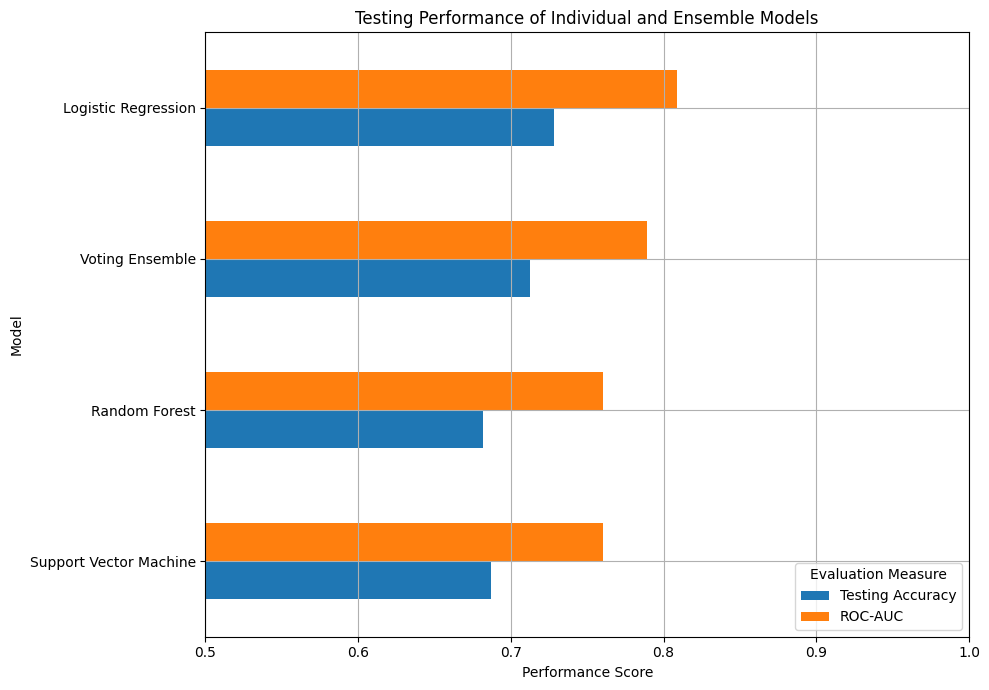

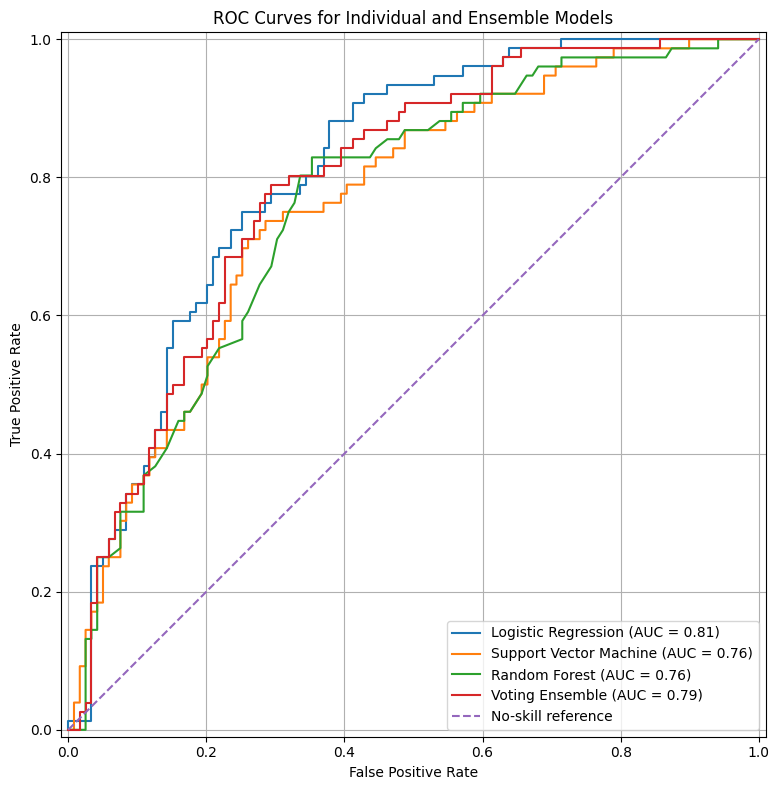

Best ensemble: Logistic Regression

Confusion matrix:
[[95 24]
 [29 47]]


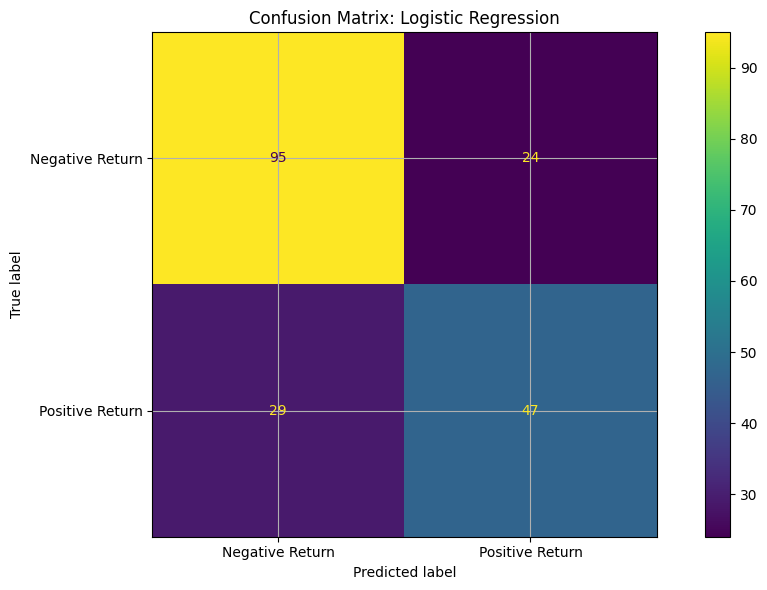

In [84]:
# ============================================================
# FIGURE 1
# TESTING ACCURACY AND ROC-AUC
# ============================================================

plot_data = (
    model_comparison[
        [
            "Model",
            "Testing Accuracy",
            "ROC-AUC"
        ]
    ]
    .set_index("Model")
    .sort_values("ROC-AUC")
)

ax = plot_data.plot(
    kind="barh",
    figsize=(10, 7)
)

ax.set_title(
    "Testing Performance of Individual "
    "and Ensemble Models"
)

ax.set_xlabel("Performance Score")
ax.set_ylabel("Model")

ax.set_xlim(
    0.50,
    1.00
)

plt.legend(
    title="Evaluation Measure",
    loc="lower right"
)

plt.tight_layout()
plt.show()

# ============================================================
# FIGURE 2
# ROC CURVES
# ============================================================

fig, ax = plt.subplots(
    figsize=(10, 8)
)

for model_name, fitted_model in (
    fitted_models.items()
):

    RocCurveDisplay.from_estimator(
        fitted_model,
        X_test,
        y_test,
        name=model_name,
        ax=ax
    )


ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="No-skill reference"
)

ax.set_title(
    "ROC Curves for Individual "
    "and Ensemble Models"
)

ax.set_xlabel(
    "False Positive Rate"
)

ax.set_ylabel(
    "True Positive Rate"
)

plt.legend(
    loc="lower right"
)

plt.tight_layout()
plt.show()
# ============================================================
# FIGURE 3
# CONFUSION MATRIX FOR THE BEST ENSEMBLE
# ============================================================

best_ensemble_name = (
    best_ensemble["Model"]
)

best_ensemble_model = fitted_models[
    best_ensemble_name
]

best_ensemble_predictions = (
    best_ensemble_model.predict(
        X_test
    )
)

best_ensemble_confusion_matrix = (
    confusion_matrix(
        y_test,
        best_ensemble_predictions
    )
)


print(
    "Best ensemble:",
    best_ensemble_name
)

print(
    "\nConfusion matrix:"
)

print(
    best_ensemble_confusion_matrix
)


ConfusionMatrixDisplay.from_predictions(
    y_test,
    best_ensemble_predictions,

    display_labels=[
        "Negative Return",
        "Positive Return"
    ]
)

plt.title(
    "Confusion Matrix: "
    + best_ensemble_name
)

plt.tight_layout()
plt.show()

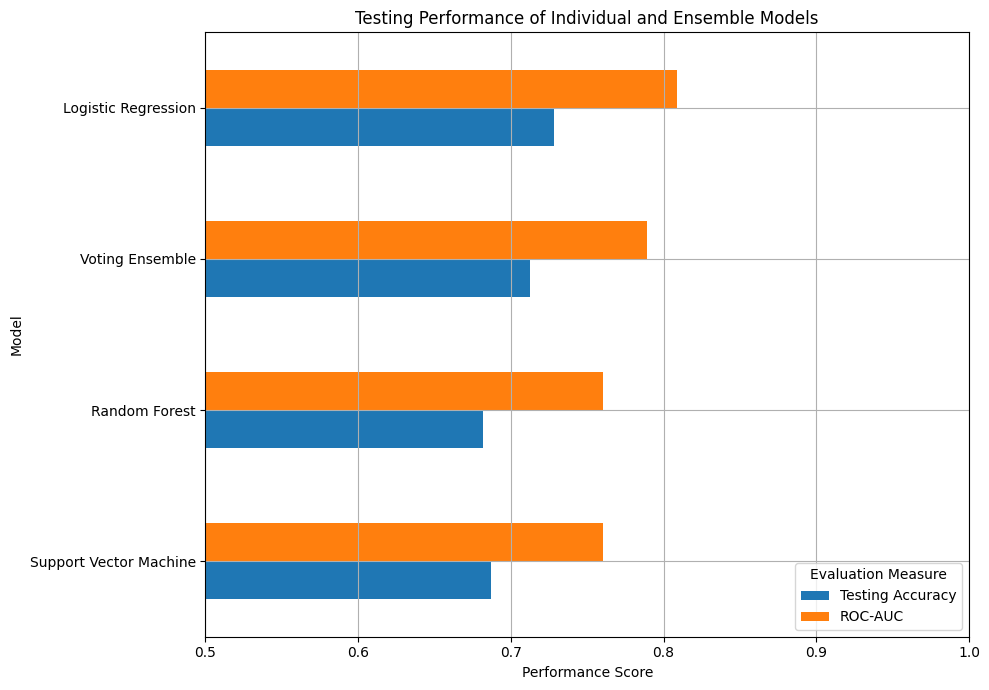

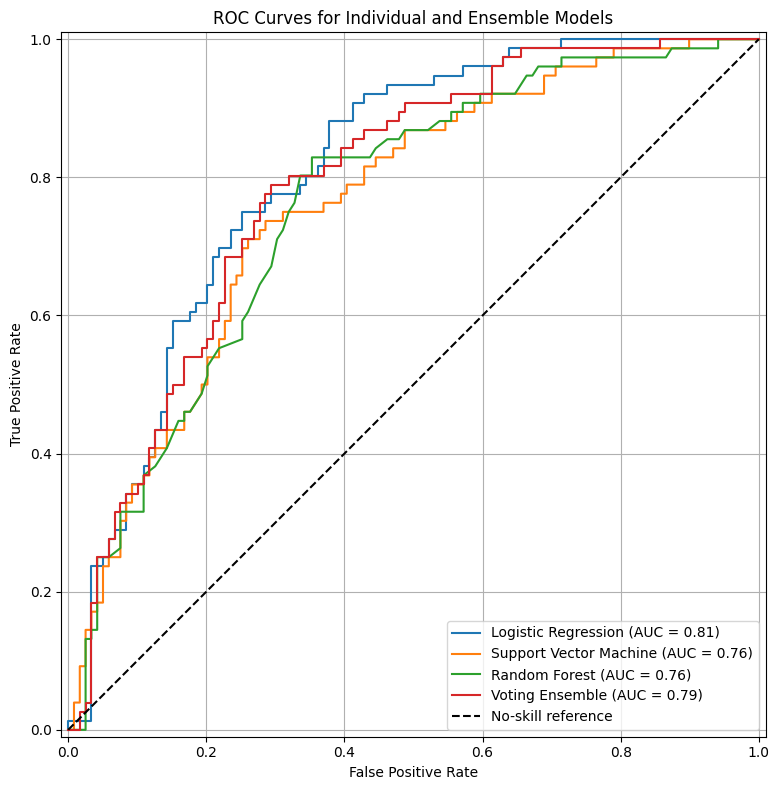

TypeError: string indices must be integers, not 'str'

In [85]:
import matplotlib.pyplot as plt

from sklearn.metrics import (
    RocCurveDisplay,
    ConfusionMatrixDisplay,
    confusion_matrix
)

# ============================================================
# FIGURE 1
# TESTING ACCURACY AND ROC-AUC
# ============================================================

plot_data = (
    model_comparison[
        ["Model", "Testing Accuracy", "ROC-AUC"]
    ]
    .copy()
    .set_index("Model")
    .sort_values(by="ROC-AUC")
)

ax = plot_data.plot(
    kind="barh",
    figsize=(10, 7)
)

ax.set_title(
    "Testing Performance of Individual and Ensemble Models"
)

ax.set_xlabel("Performance Score")
ax.set_ylabel("Model")
ax.set_xlim(0.50, 1.00)

plt.legend(
    title="Evaluation Measure",
    loc="lower right"
)

plt.tight_layout()
plt.show()


# ============================================================
# FIGURE 2
# ROC CURVES
# ============================================================

fig, ax = plt.subplots(figsize=(10, 8))

for model_name, fitted_model in fitted_models.items():

    try:
        RocCurveDisplay.from_estimator(
            fitted_model,
            X_test,
            y_test,
            name=model_name,
            ax=ax
        )

    except Exception as e:
        print(f"Skipping {model_name}: {e}")

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="black",
    label="No-skill reference"
)

ax.set_title(
    "ROC Curves for Individual and Ensemble Models"
)

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")

plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


# ============================================================
# FIGURE 3
# CONFUSION MATRIX FOR THE BEST ENSEMBLE
# If best_ensemble is a DataFrame
if hasattr(best_ensemble, "iloc"):
    best_ensemble_name = best_ensemble.iloc[0]["Model"]
else:
    best_ensemble_name = best_ensemble["Model"]

best_ensemble_model = fitted_models[best_ensemble_name]

best_predictions = best_ensemble_model.predict(X_test)

cm = confusion_matrix(
    y_test,
    best_predictions
)

print(f"Best ensemble: {best_ensemble_name}")
print("\nConfusion Matrix:")
print(cm)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    best_predictions,
    display_labels=[
        "Negative Return",
        "Positive Return"
    ]
)

plt.title(f"Confusion Matrix: {best_ensemble_name}")
plt.tight_layout()
plt.show()